In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import RXGate, RYGate, CZGate, MCXGate, RZGate, MCMT
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import  SamplerV2 as Sampler
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
 
from qiskit_ibm_runtime.fake_provider import FakeBrisbane

import numpy as np

from Circuits import build_circuit, build_r0lstar, build_transition

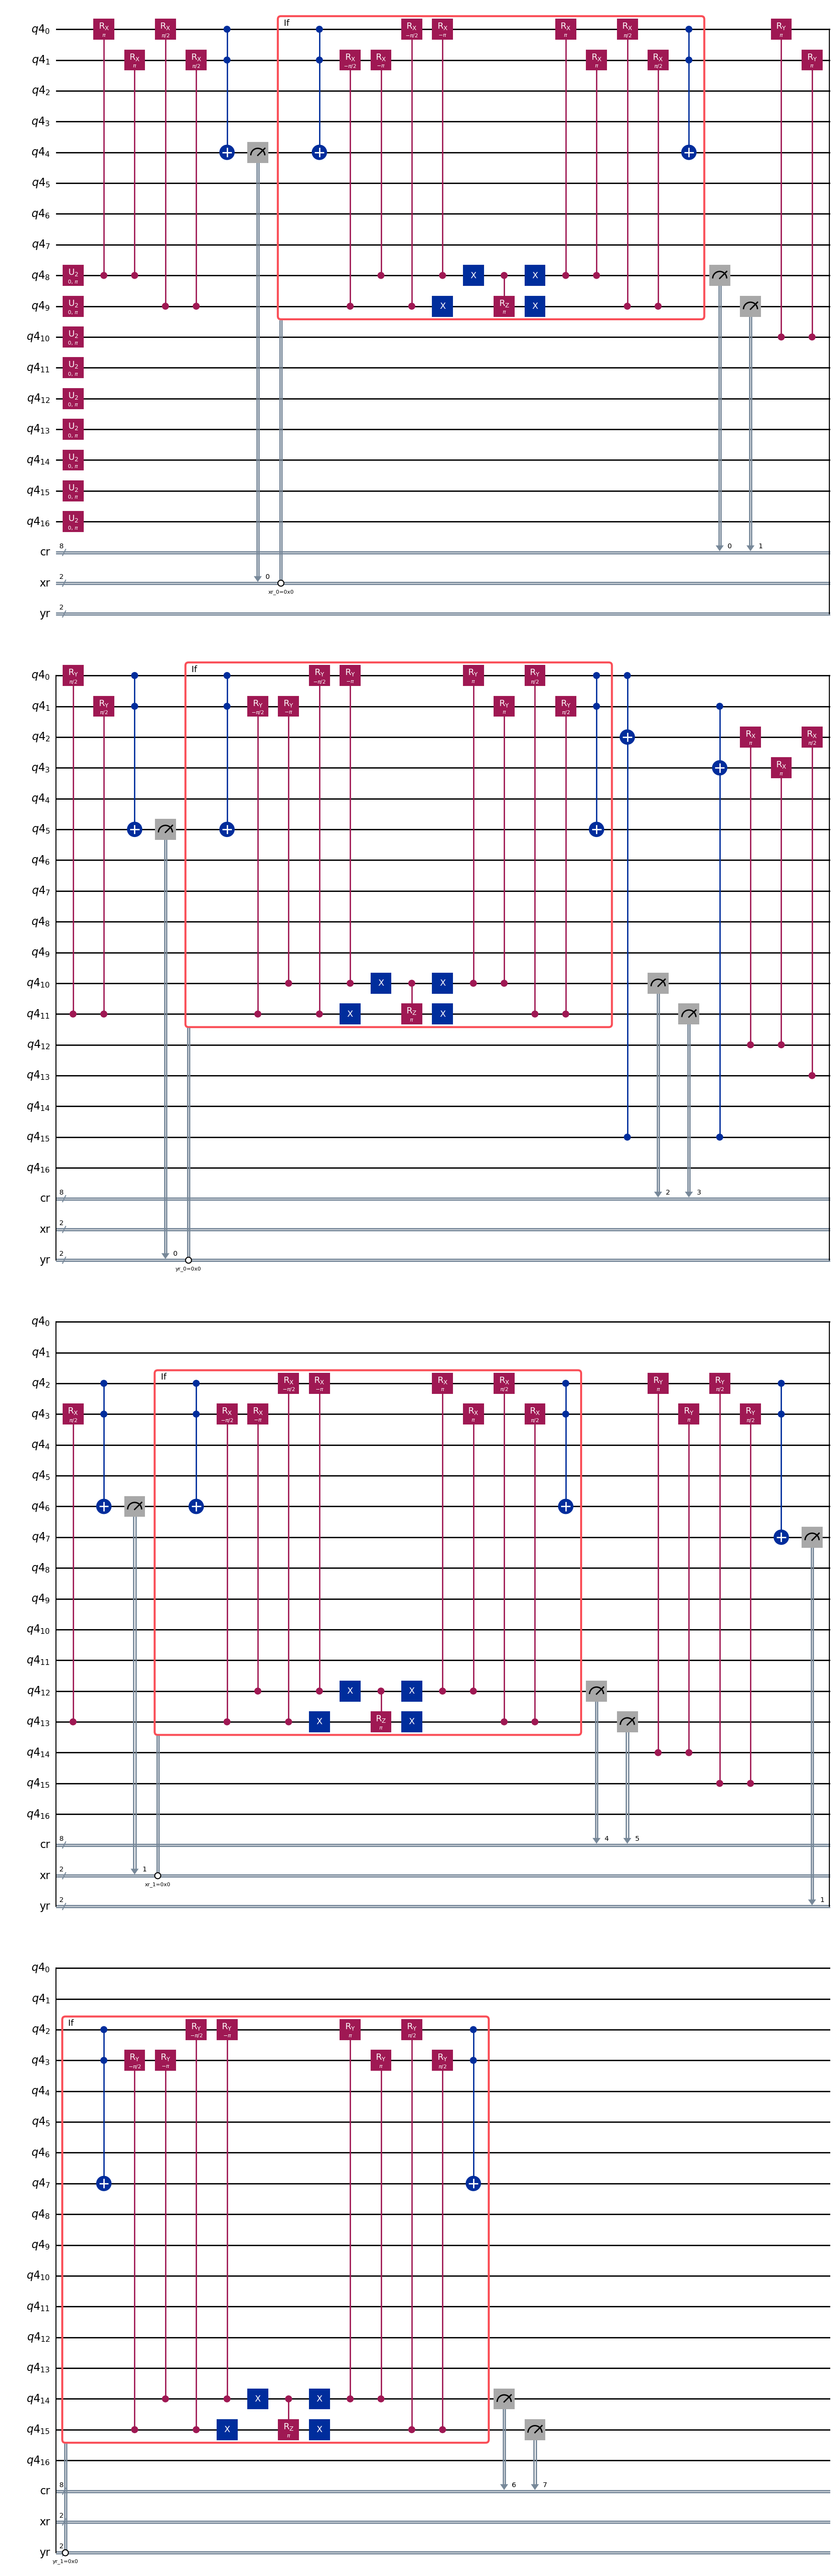

In [37]:
# create the circuit
X = np.array([[1, 1], [1, 1]])
R = 2

circuit = build_circuit(X, R)
circuit.decompose().draw(output='mpl')

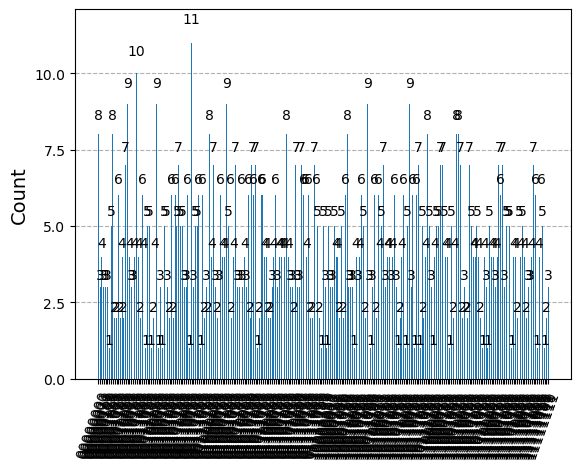

In [ ]:
# obtain a distribution of possible results
# set up the backend
backend = AerSimulator()
sampler = Sampler(mode=backend)

results = sampler.run([circuit.decompose()]).result()

# plot the distribution of the counts
counts = results[0].data.cr.get_counts()
plot_histogram(counts)

In [35]:
# run experiments based on results

experiment_results = {}

counter = 1

# for each key, run an experiment
for key in list(counts.keys()):
	print(f"Testing {counter} of {len(list(counts.keys()))}")
	iterations = counts[key]

	# runs an experiment based on the parameters for which Rx, Ry parameters are applied
	qc = QuantumCircuit(X.shape[1])
	for b in range(X.shape[1]):
		for r in range(R): 
			# retrieve the result
			if int(key[b * R * 2 + r]) == 1:
				qc.rx(np.pi / (2**r), b)
			
			if int(key[b * R * 2 + R + r]) == 1:
				qc.ry(np.pi / (2**r), b)
	
	qc.measure_all()

	for _ in range(iterations):
		# run the circuit
		backend = AerSimulator()
		sampler = Sampler(mode=backend)

		experiment_result = sampler.run([qc]).result()
		experiment_count = experiment_result[0].data.meas.get_counts()
		experiment_results.update(experiment_count)

	counter += 1

Testing 1 of 248
Testing 2 of 248
Testing 3 of 248
Testing 4 of 248
Testing 5 of 248
Testing 6 of 248
Testing 7 of 248
Testing 8 of 248
Testing 9 of 248
Testing 10 of 248
Testing 11 of 248
Testing 12 of 248
Testing 13 of 248
Testing 14 of 248
Testing 15 of 248
Testing 16 of 248
Testing 17 of 248
Testing 18 of 248
Testing 19 of 248
Testing 20 of 248
Testing 21 of 248
Testing 22 of 248
Testing 23 of 248
Testing 24 of 248
Testing 25 of 248
Testing 26 of 248
Testing 27 of 248
Testing 28 of 248
Testing 29 of 248
Testing 30 of 248
Testing 31 of 248
Testing 32 of 248
Testing 33 of 248
Testing 34 of 248
Testing 35 of 248
Testing 36 of 248
Testing 37 of 248
Testing 38 of 248
Testing 39 of 248
Testing 40 of 248
Testing 41 of 248
Testing 42 of 248
Testing 43 of 248
Testing 44 of 248
Testing 45 of 248
Testing 46 of 248
Testing 47 of 248
Testing 48 of 248
Testing 49 of 248
Testing 50 of 248
Testing 51 of 248
Testing 52 of 248
Testing 53 of 248
Testing 54 of 248
Testing 55 of 248
Testing 56 of 248
T

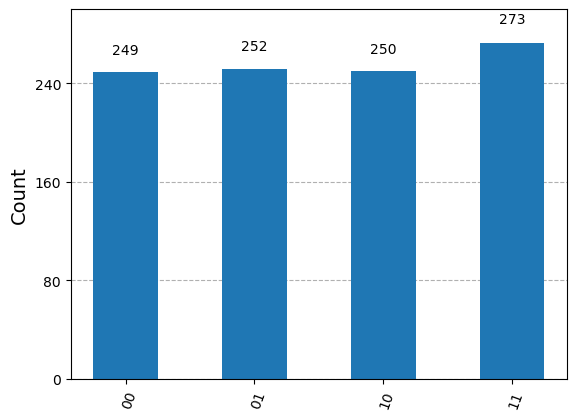

In [36]:
plot_histogram(experiment_results)

## Archived

In [ ]:
def build_rx(N, R):
    rx_circuit = QuantumCircuit(N + R + 1)

    # apply Rx rotation gates
    for i in range(N):
        for r in range(R):
            gate = RXGate(np.pi / (2**r))
            rx_circuit.append(gate.control(1), (N + 1 + r, i))

    return rx_circuit

def build_ry(N, R):
    ry_circuit = QuantumCircuit(N + R + 1)

    # apply Rx rotation gates
    for i in range(N):
        for r in range(R):
            gate = RYGate(np.pi / (2**r))
            ry_circuit.append(gate.control(1), (N + 1 + r, i))

    return ry_circuit

def build_transition(N):
    transition_circ = QuantumCircuit(2*N + 1)

    for i in range(N):
        transition_circ.append(MCXGate(2), (i, 2*N, N + i))

    return transition_circ

def build_r0lstar(R):
    # target + all of the R rotation controls
    r0lstar_circuit = QuantumCircuit(R)

    r0lstar_circuit.x(list(range(R)))
    r0lstar_circuit.mcrz(np.pi, list(range(R-1)), R-1)
    r0lstar_circuit.x(list(range(R)))

    return r0lstar_circuit

In [ ]:
## TESTING ENVIRONMENT
# convert to NP array
X = np.array(X)

N = X.shape[0] # number of data points
B = X.shape[1] # number of bits

size = (N + 2 + 2*R) * B + B - 1
num_rotation_param = 2 * R * B

qr = QuantumRegister(size)
cr = ClassicalRegister(num_rotation_param, name='cr')
xr = ClassicalRegister(B, name='xr')
yr = ClassicalRegister(B, name='yr')

# initialize circuit
circuit = QuantumCircuit(qr, cr, xr, yr)

circuit.h(list(range(N*B + 2*B, (N + 2 + 2*R) * B + B - 1)))

rx_block = build_rx(N, R).to_gate()
ry_block = build_ry(N, R).to_gate()
transition_block = build_transition(N).to_gate(label='transition block')

r0lstar = build_r0lstar(R).to_gate(label='r0lstar')

for i in range(B):
    # apply RX block (data + target + rotation)
    rx_target_index = N*B + 2*i
    rx_lanes = list(range(i * N, (i + 1) * N)) + [rx_target_index] + list(range(N*B + 2*B + 2*R*i, N*B + 2*B + 2*R*i + R))

    # add the X-gates for bits with 0
    rx_circuit = QuantumCircuit(N + R + 1)

    # apply Rx rotation gates
    for j in range(N):
        for r in range(R):
            gate = RXGate(np.pi / (2**r))
            rx_circuit.append(gate.control(1), (N + 1 + r, j))
            
    # rx_bit_i = QuantumCircuit(rx_block.num_qubits)
    # rx_bit_i.append(rx_block, list(range(rx_block.num_qubits)))
    for d in range(N):
        if X[d][i] == 0:
            # add X values for all bits with 0's
            rx_circuit.x(d)

    # apply CNOT gate to target
    rx_circuit.append(MCXGate(N), list(range(0, N+1)))
    rx_circuit = rx_circuit.to_gate(label='ctrl-Rx block')

    circuit.append(rx_circuit, rx_lanes)
    
    # measure
    circuit.measure(rx_target_index, xr[i])

    # OAA
    with circuit.if_test((xr[i], 0)):
        rx_inv = rx_circuit.inverse()
        rx_inv.label = 'ctrl-Rx inverse'
        circuit.append(rx_inv, rx_lanes)
        r0lstar_lanes = list(range(N*B + 2*B + 2*R*i, N*B + 2*B + 2*R*i + R))
        circuit.append(r0lstar, r0lstar_lanes)
        circuit.append(rx_circuit, rx_lanes)

    # apply Ry block
    ry_target_index = N*B + 2*i + 1
    ry_lanes = list(range(i * N, (i + 1) * N)) + [ry_target_index] + list(range(N*B + 2*B + 2*R*i + R, N*B + 2*B + 2*R*i + 2*R))

    # add the X gates for bits with 0
    ry_circuit = QuantumCircuit(N + R + 1)

    # apply Rx rotation gates
    for j in range(N):
        for r in range(R):
            gate = RYGate(np.pi / (2**r))
            ry_circuit.append(gate.control(1), (N + 1 + r, j))
            
    # ry_bit_i = QuantumCircuit(ry_block.num_qubits)
    # ry_bit_i.append(rx_block, list(range(ry_block.num_qubits)))
    for d in range(N):
        if X[d][i] == 0:
            # add X values for all bits with 0's
            ry_circuit.x(d)

    # apply CNOT gate to target
    ry_circuit.append(MCXGate(N), list(range(0, N+1)))
    ry_circuit = ry_circuit.to_gate(label='ctrl-Ry block')

    circuit.append(ry_circuit, ry_lanes)
    
    # measure
    circuit.measure(ry_target_index, yr[i])

    # OAA
    with circuit.if_test((yr[i], 0)):
        ry_inv = ry_circuit.inverse()
        ry_inv.label = 'ctrl-Ry inverse'
        circuit.append(ry_inv, ry_lanes)
        r0lstar_lanes = list(range(N*B + 2*B + 2*R*i + R, N*B + 2*B + 2*R*i + 2*R))
        circuit.append(r0lstar, r0lstar_lanes)
        circuit.append(ry_circuit, ry_lanes)
    
    if i != B - 1:
        # apply the transition from bit i to bit i + 1
        transition_lanes = list(range(i * N, (i + 2) * N)) + [size - B + i] # [consecutive lanes] + [control]
        # apply transition block
        circuit.append(transition_block, transition_lanes)
        
circuit.measure(qr[N*B + 2*B:N*B + 2*B + 2*R*B], cr)

# decomposed = circuit.decompose()
circuit.draw(output='mpl')

In [99]:
def old_build_circuit(X, R):
	'''
	args:
		X: array of data points
		R: rotation precision
	returns:
		circuit: complete circuit
	'''
	# convert to NP array
	X = np.array(X)

	N = X.shape[0] # number of data points
	B = X.shape[1] # number of bits

	size = (N + 2 + 2*R) * B + B - 1
	# num_rotation_ctrls = ...

	qr = QuantumRegister(size)
	# cr = ClassicalRegister(num_rotation_ctrls, name='cr')
	cr = ClassicalRegister(size, name='cr')
	xr = ClassicalRegister(1, name='xr')
	yr = ClassicalRegister(1, name='yr')

	# initialize circuit
	circuit = QuantumCircuit(qr, cr, xr, yr)

	circuit.h(list(range(N*B + 2*B, (N + 2 + 2*R) * B + B - 1)))

	rx_block = build_rx(N, R)
	ry_block = build_ry(N, R)
	transition_block = build_transition(N).to_gate(label='Transition')

	r0lstar = build_r0lstar(R).to_gate(label='r0lstar')

	for i in range(B):
		# apply RX block (data + target + rotation)
		rx_target_index = N*B + 2*i
		rx_lanes = list(range(i * N, (i + 1) * N)) + [rx_target_index] + list(range(N*B + 2*B + 2*R*i, N*B + 2*B + 2*R*i + R))

		# add the X-gates for bits with 0
		rx_bit_i = QuantumCircuit(rx_block.num_qubits)
		rx_bit_i.append(rx_block, list(range(rx_block.num_qubits)))
		for d in range(N):
			if X[d][i] == 0:
				# add X values for all bits with 0's
				rx_bit_i.x(d)

		# apply CNOT gate to target
		rx_bit_i.append(MCXGate(N), list(range(0, N+1)))

		circuit.append(rx_bit_i, rx_lanes)
		
		# measure
		circuit.measure(rx_target_index, xr)

		# OAA
		with circuit.if_test((xr, 0)):
			circuit.append(rx_bit_i.inverse(), rx_lanes)
			r0lstar_lanes = list(range(N*B + 2*B + 2*R*i, N*B + 2*B + 2*R*i + R))
			circuit.append(r0lstar, r0lstar_lanes)
			circuit.append(rx_bit_i, rx_lanes)

		# apply Ry block
		ry_target_index = N*B + 2*i + 1
		ry_lanes = list(range(i * N, (i + 1) * N)) + [ry_target_index] + list(range(N*B + 2*B + 2*R*i + R, N*B + 2*B + 2*R*i + 2*R))

		# add the X gates for bits with 0
		ry_bit_i = QuantumCircuit(ry_block.num_qubits)
		ry_bit_i.append(rx_block, list(range(ry_block.num_qubits)))
		for d in range(N):
			if X[d][i] == 0:
				# add X values for all bits with 0's
				ry_bit_i.x(d)

		# apply CNOT gate to target
		ry_bit_i.append(MCXGate(N), list(range(0, N+1)))

		circuit.append(ry_bit_i, ry_lanes)
		
		# measure
		circuit.measure(ry_target_index, yr)

		# OAA
		with circuit.if_test((yr, 0)):
			circuit.append(ry_bit_i.inverse(), ry_lanes)
			r0lstar_lanes = list(range(N*B + 2*B + 2*R*i + R, N*B + 2*B + 2*R*i + 2*R))
			circuit.append(r0lstar, r0lstar_lanes)
			circuit.append(ry_bit_i, ry_lanes)
		
		if i != B - 1:
			# apply the transition from bit i to bit i + 1
			transition_lanes = list(range(i * N, (i + 2) * N)) + [size - B + i] # [consecutive lanes] + [control]
			# apply transition block
			circuit.append(transition_block, transition_lanes)
			
	circuit.measure(qr, cr)
	# circuit.measure(qr[N * B + 2 * B + 2 * R * B:size - B], cr)

	return circuit

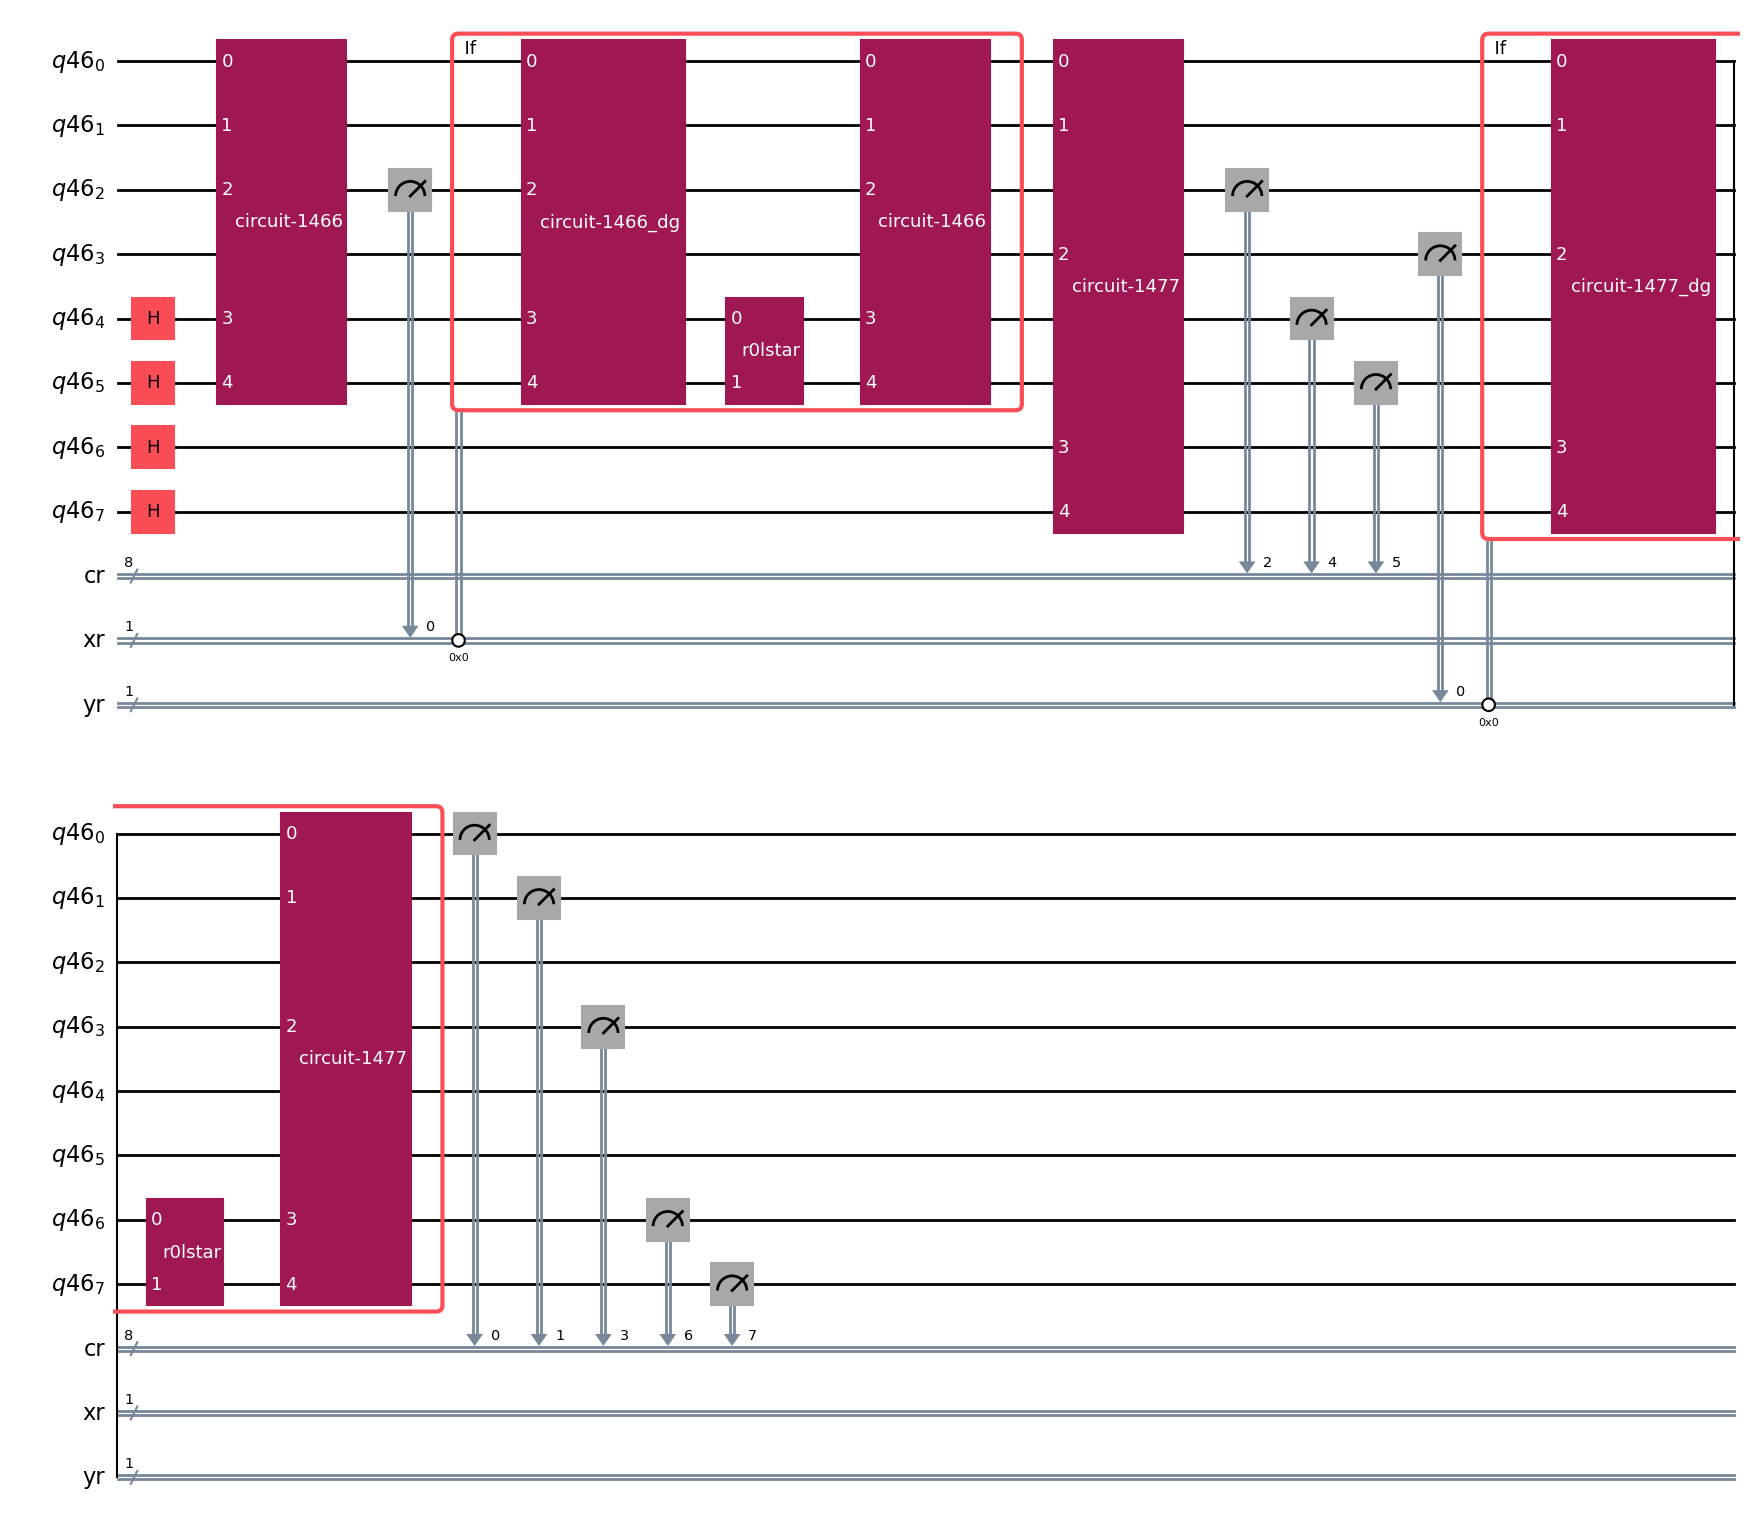

In [100]:
X = [[0], [1]]
R = 2
circuit = build_circuit(X, R)
# decomposed = circuit.decompose()
circuit.draw(output='mpl')

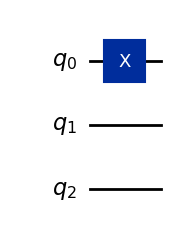

In [44]:
qc = QuantumCircuit(3)
qc.x(0)
qc.draw(output='mpl')

In [45]:
qc.measure_all()

backend = AerSimulator()
sampler = Sampler(backend=backend)

result = sampler.run([qc]).result()
result[0].data.meas.get_counts()

/var/folders/f0/g9bnvrbs7t15psm7b2d81gnm0000gn/T/ipykernel_21802/1187965836.py:4: DeprecationWarning: The 'backend' keyword arguments are deprecated as of qiskit-ibm-runtime 0.24.0 and will be removed no sooner than 3 months after the release date. Please use the 'mode' parameter instead.
  sampler = Sampler(backend=backend)


{'001': 1024}